<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_19176/4020365373.py:49: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_title('Potencial Eléctrico $\phi(x,y)$', fontsize=14)


Calculando el potencial eléctrico...
Convergencia alcanzada en la iteración 1848.


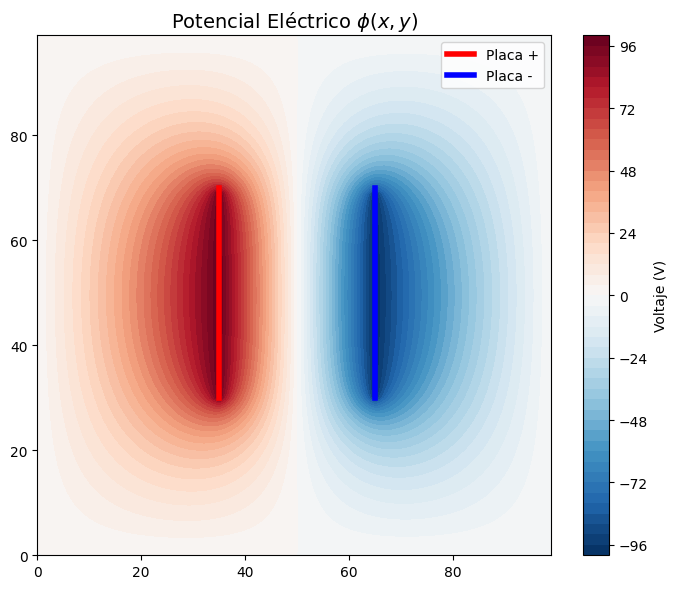

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros de la simulación ---
Nx, Ny = 100, 100
max_iter = 5000
tol = 1e-4

# Se inicializa la matriz del potencial (phi) con ceros
phi = np.zeros((Ny, Nx))

# --- Definición del Capacitor ---
x_placa_positiva = 35
x_placa_negativa = 65
y_inicio_placa = 30
y_fin_placa = 70

Voltaje_positivo = 100.0
Voltaje_negativo = -100.0

# Se aplican las condiciones de frontera de Dirichlet en las placas
phi[y_inicio_placa:y_fin_placa, x_placa_positiva] = Voltaje_positivo
phi[y_inicio_placa:y_fin_placa, x_placa_negativa] = Voltaje_negativo

# --- Solución de la Ecuación de Laplace ---
print("Calculando el potencial eléctrico...")
for k in range(max_iter):
    phi_old = phi.copy()

    # Se recorre el espacio interior
    for i in range(1, Ny-1):
        for j in range(1, Nx-1):


            phi[i, j] = 0.25 * (phi[i+1, j] + phi[i-1, j] + phi[i, j+1] + phi[i, j-1])

    # Verificación de convergencia
    if np.max(np.abs(phi - phi_old)) < tol:
        print(f"Convergencia alcanzada en la iteración {k}.")
        break


fig, ax1 = plt.subplots(figsize=(7, 6))

im1 = ax1.contourf(phi, levels=50, cmap='RdBu_r')
ax1.set_title('Potencial Eléctrico $\phi(x,y)$', fontsize=14)
fig.colorbar(im1, ax=ax1, label='Voltaje (V)')

# Se dibujan las placas físicamente
ax1.plot([x_placa_positiva, x_placa_positiva], [y_inicio_placa, y_fin_placa], color='red', linewidth=4, label='Placa +')
ax1.plot([x_placa_negativa, x_placa_negativa], [y_inicio_placa, y_fin_placa], color='blue', linewidth=4, label='Placa -')
ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

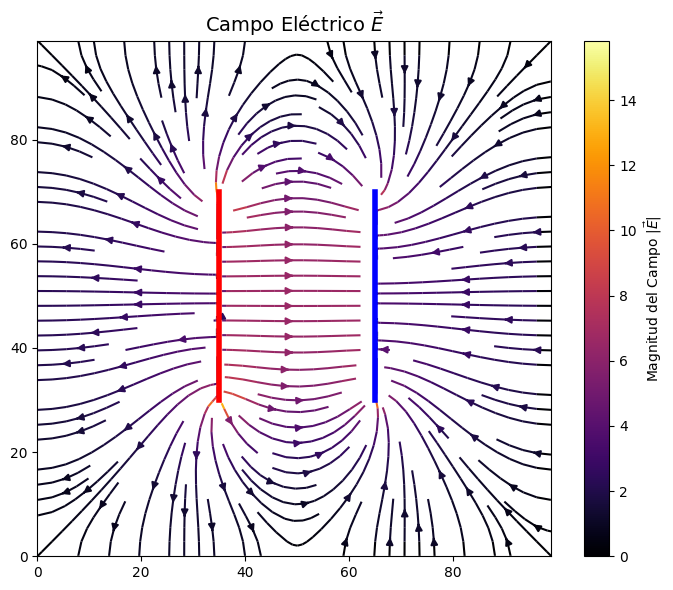

In [14]:

Nx, Ny = 100, 100
max_iter = 5000
tol = 1e-4
phi = np.zeros((Ny, Nx))

x_placa_positiva = 35
x_placa_negativa = 65
y_inicio_placa = 30
y_fin_placa = 70

phi[y_inicio_placa:y_fin_placa, x_placa_positiva] = 100.0
phi[y_inicio_placa:y_fin_placa, x_placa_negativa] = -100.0


for k in range(max_iter):
    phi_old = phi.copy()
    for i in range(1, Ny-1):
        for j in range(1, Nx-1):
            if (j == x_placa_positiva or j == x_placa_negativa) and (y_inicio_placa <= i < y_fin_placa):
                continue
            phi[i, j] = 0.25 * (phi[i+1, j] + phi[i-1, j] + phi[i, j+1] + phi[i, j-1])
    if np.max(np.abs(phi - phi_old)) < tol:
        break


Ex = np.zeros((Ny, Nx))
Ey = np.zeros((Ny, Nx))

# Se asume que la distancia espacial entre puntos de la cuadrícula es de 1 unidad
dx = 1.0
dy = 1.0

# Se recorre la matriz omitiendo los bordes extremos (0 y N-1)
for i in range(1, Ny-1):
    for j in range(1, Nx-1):

        # Se aplica la aproximación de diferencias finitas centrales para X
        dphi_dx = (phi[i, j+1] - phi[i, j-1]) / (2 * dx)
        Ex[i, j] = -dphi_dx

        # Se aplica la misma lógica adaptada para el eje Y
        dphi_dy = (phi[i+1, j] - phi[i-1, j]) / (2 * dy)
        Ey[i, j] = -dphi_dy


fig, ax2 = plt.subplots(figsize=(7, 6))

Y, X = np.mgrid[0:Ny, 0:Nx]

# Se calcula la magnitud del campo para asignar un mapa de color a las líneas
Magnitud_E = np.sqrt(Ex**2 + Ey**2)

strm = ax2.streamplot(X, Y, Ex, Ey, color=Magnitud_E, cmap='inferno', linewidth=1.5, density=1.2)
ax2.set_title('Campo Eléctrico $\\vec{E}$', fontsize=14)
fig.colorbar(strm.lines, ax=ax2, label='Magnitud del Campo $|\\vec{E}|$')

# Se superponen las placas en el gráfico del campo vectorial
ax2.plot([x_placa_positiva, x_placa_positiva], [y_inicio_placa, y_fin_placa], color='red', linewidth=4)
ax2.plot([x_placa_negativa, x_placa_negativa], [y_inicio_placa, y_fin_placa], color='blue', linewidth=4)

plt.tight_layout()
plt.show()